# PAMAP2 Few-Shot Learning (k-shot) — **Explainable** Notebook
## Contrastive few-shot + Transformer Label Embeddings + Prototype Refinement + Rich EDA

**What you asked for:** more EDA, more visualisations, clearer per‑epoch logging, and explanations of what each cell is doing.

This notebook is self‑contained and reproducible. It keeps the **same data extraction / folder structure**:

```
PAMAP2_Dataset/
  Protocol/ subject1.dat ... subject9.dat
  Optional/ subject1.dat ... subject9.dat
```

### Pipeline (high level)
1. Load Protocol + Optional data
2. Clean + impute missing values (per subject/session)
3. Create fixed‑length windows + purity filtering (remove transition windows)
4. Split into:
   - **Train/Val:** SEEN classes only  
   - **Test:** UNSEEN classes only
5. Build **label prototypes** using a pretrained transformer (Sentence‑BERT)
6. Train a time‑series encoder (TCN) with **contrastive loss over prototypes**
7. Evaluate few-shot:
   - Baseline nearest‑prototype
   - **Prototype refinement** (pseudo‑label transductive refinement)
8. Visualise:
   - Label distributions, missingness, window purity
   - Example sensor windows
   - Label‑prototype similarity heatmap
   - t‑SNE: prototypes + unseen window embeddings

> Timestamp: 2026-01-23T04:17:38

## 0) Setup

This cell:
- imports libraries
- sets random seeds (reproducible)
- chooses GPU if available
- applies two practical macOS/Jupyter fixes:
  - `TOKENIZERS_PARALLELISM=false` (silences HuggingFace fork warning)
  - `num_workers=0` for DataLoader (avoids spawn/pickling issues)

In [1]:
import os, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE

# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# --- macOS/Jupyter stability ---
os.environ["TOKENIZERS_PARALLELISM"] = "false"
NUM_WORKERS = 0

DEVICE: cpu


## 1) Activity IDs + names

We define the PAMAP2 activity IDs and readable names for plotting and reporting.

In [2]:
ACTIVITY_MAP = {
    1: "lying",
    2: "sitting",
    3: "standing",
    4: "walking",
    5: "running",
    6: "cycling",
    7: "Nordic walking",
    9: "watching TV",
    10: "computer work",
    11: "car driving",
    12: "ascending stairs",
    13: "descending stairs",
    16: "vacuum cleaning",
    17: "ironing",
    18: "folding laundry",
    19: "house cleaning",
    20: "playing soccer",
    24: "rope jumping",
}

LABEL_TEXT = {
    1:  "lying quietly while doing nothing; small movements allowed (e.g., changing posture)",
    2:  "sitting in a chair in any comfortable posture; changing sitting postures allowed",
    3:  "standing still or standing and talking; gesticulating possible",
    17: "ironing 1-2 shirts or T-shirts",
    16: "vacuum cleaning one or two rooms; includes moving objects (e.g., chairs) on the floor",
    12: "ascending stairs across multiple floors (five floors) going upstairs",
    13: "descending stairs across multiple floors (five floors) going downstairs",
    4:  "walking outside with moderate to brisk pace (4-6 km/h)",
    7:  "Nordic walking outside using poles; subjects not very familiar with the activity",
    6:  "cycling outside with real bike at slow to moderate pace (not sport pace)",
    5:  "running/jogging outside at a suitable speed for the subject",
    24: "rope jumping; basic jump or alternate foot jump; repeated vertical jumps",
    9:  "watching TV at home; posture can be lying or sitting",
    10: "computer work; working normally in the office",
    11: "car driving between office and home",
    18: "folding shirts, T-shirts and/or bed linens",
    19: "house cleaning; dusting shelves; removing books/things and putting them back",
    20: "playing soccer 1v1 or 2v1; running with ball, dribbling, passing, shooting",
}

## 2) Load PAMAP2 Protocol + Optional 

This cell:
- defines the 54 raw column names (timestamp, label, HR, 3 IMUs × 17 channels)
- reads `subject*.dat` from `Protocol/` and `Optional/`
- concatenates everything into one table

In [3]:
DATA_ROOT = "PAMAP2_Dataset"  # change if needed

def make_colnames():
    cols = ["timestamp", "label", "hr"]
    imu_parts = [
        "temp",
        "acc16_x","acc16_y","acc16_z",
        "acc6_x","acc6_y","acc6_z",
        "gyro_x","gyro_y","gyro_z",
        "mag_x","mag_y","mag_z",
        "ori_1","ori_2","ori_3","ori_4",
    ]
    for loc in ["hand","chest","ankle"]:
        cols += [f"{loc}_{p}" for p in imu_parts]
    assert len(cols) == 54
    return cols

COLS = make_colnames()

def load_all_sessions(data_root=DATA_ROOT):
    dfs = []
    for part in ["Protocol","Optional"]:
        folder = os.path.join(data_root, part)
        for f in sorted(glob.glob(os.path.join(folder, "subject*.dat"))):
            df = pd.read_csv(f, sep=r"\s+", header=None, names=COLS, engine="python")
            df["session"] = part.lower()
            df["subject"] = os.path.splitext(os.path.basename(f))[0]  # e.g., subject1
            dfs.append(df)
    if not dfs:
        raise FileNotFoundError("No subject*.dat found. Check DATA_ROOT/Protocol and DATA_ROOT/Optional.")
    return pd.concat(dfs, ignore_index=True)

raw = load_all_sessions()
print("Raw shape:", raw.shape)
raw.head(2)

Raw shape: (3850505, 56)


,timestamp,label,hr,hand_temp,hand_acc16_x,hand_acc16_y,hand_acc16_z,hand_acc6_x,hand_acc6_y,hand_acc6_z,...,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,ankle_ori_1,ankle_ori_2,ankle_ori_3,ankle_ori_4,session,subject
0,8.38,0,104.0,30.0,2.37223,8.60074,3.51048,2.43954,8.76165,3.35465,...,-0.017580,-61.1888,-38.9599,-58.1438,1.0,0.0,0.0,0.0,protocol,subject101
1,8.39,0,NaN,30.0,2.18837,8.56560,3.66179,2.39494,8.55081,3.64207,...,0.000368,-59.8479,-38.8919,-58.5253,1.0,0.0,0.0,0.0,protocol,subject101


## 3) Quick EDA on raw data

We look at:
- available labels
- sessions/subjects
- missingness rate (NaNs are expected in PAMAP2)

In [4]:
print("Subjects:", raw["subject"].nunique(), "| Sessions:", raw["session"].unique())
print("Unique labels (raw):", sorted(raw["label"].dropna().unique().astype(int).tolist())[:30], "...")
print("Overall NaN fraction (raw):", float(raw.isna().mean().mean()))

# How much label==0 exists (transient)
if "label" in raw.columns:
    z0 = (raw["label"] == 0).mean()
    print("Transient label==0 fraction:", float(z0))

Subjects: 9 | Sessions: ['protocol' 'optional']
Unique labels (raw): [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 16, 17, 18, 19, 20, 24] ...
Overall NaN fraction (raw): 0.018765720340578707
Transient label==0 fraction: 0.29231282649938123


### Visualisation 3A — Missing values by column (top 25)

This helps you see which sensors/channels are missing often.

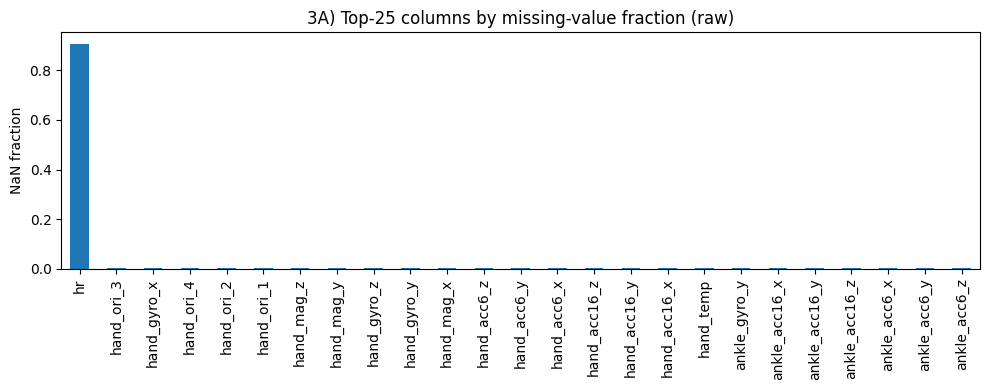

In [5]:
nan_by_col = raw.isna().mean().sort_values(ascending=False)
plt.figure(figsize=(10,4))
nan_by_col.head(25).plot(kind="bar")
plt.title("3A) Top-25 columns by missing-value fraction (raw)")
plt.ylabel("NaN fraction")
plt.tight_layout()
plt.show()

## 4) Preprocess (impute NaNs; drop transient label 0; drop invalid orientation; drop acc6)

Why:
- orientation channels are invalid in this dataset
- acc6 sometimes saturates; PAMAP2 recommends using acc16
- we **impute** missing values per subject/session to avoid dropping everything

Outputs:
- `df`: cleaned dataframe
- `FEATURE_COLS`: list of numeric features used by the model

In [6]:
ORI_COLS  = [c for c in COLS if "_ori_" in c]
ACC6_COLS = [c for c in COLS if "_acc6_" in c]

def preprocess_pamap2(df: pd.DataFrame,
                      drop_orientation: bool = True,
                      drop_acc6: bool = True,
                      keep_hr: bool = True,
                      max_nan_frac_per_row: float = 0.30) -> pd.DataFrame:
    df = df.copy()

    # Ensure numeric label
    df["label"] = pd.to_numeric(df["label"], errors="coerce")
    df = df[df["label"].notna()]
    df["label"] = df["label"].astype(int)

    # Drop transient
    df = df[df["label"] != 0].reset_index(drop=True)

    # Drop problematic channels
    if drop_orientation:
        df = df.drop(columns=ORI_COLS, errors="ignore")
    if drop_acc6:
        df = df.drop(columns=ACC6_COLS, errors="ignore")
    if not keep_hr:
        df = df.drop(columns=["hr"], errors="ignore")

    # Force numeric for features
    for c in df.columns:
        if c not in ["subject","session"]:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    feat_cols = [c for c in df.columns if c not in ["subject","session","label"]]

    # Impute within each subject/session in time order
    def impute_group(g):
        g = g.sort_values("timestamp")
        g[feat_cols] = g[feat_cols].interpolate(limit_direction="both")
        g[feat_cols] = g[feat_cols].ffill().bfill()
        return g

    df = df.groupby(["subject","session"], group_keys=False).apply(impute_group)

    # Drop rows with excessive missingness (after interpolation)
    nan_frac = df[feat_cols].isna().mean(axis=1)
    df = df[nan_frac <= max_nan_frac_per_row].reset_index(drop=True)

    df = df.dropna().reset_index(drop=True)
    return df

df = preprocess_pamap2(raw)
print("Preprocessed shape:", df.shape)
df.head(2)

Preprocessed shape: (2724953, 35)


,timestamp,label,hr,hand_temp,hand_acc16_x,hand_acc16_y,hand_acc16_z,hand_gyro_x,hand_gyro_y,hand_gyro_z,...,ankle_acc16_y,ankle_acc16_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,session,subject
0,37.66,1,100.0,30.375,2.21530,8.27915,5.58753,-0.00475,0.037579,-0.011145,...,-1.84761,0.095156,0.002908,-0.027714,0.001752,-61.1081,-36.8636,-58.3696,protocol,subject101
1,37.67,1,100.0,30.375,2.29196,7.67288,5.74467,-0.17171,0.025479,-0.009538,...,-1.88438,-0.020804,0.020882,0.000945,0.006007,-60.8916,-36.3197,-58.3656,protocol,subject101


### Visualisation 4A — Label distribution after preprocessing

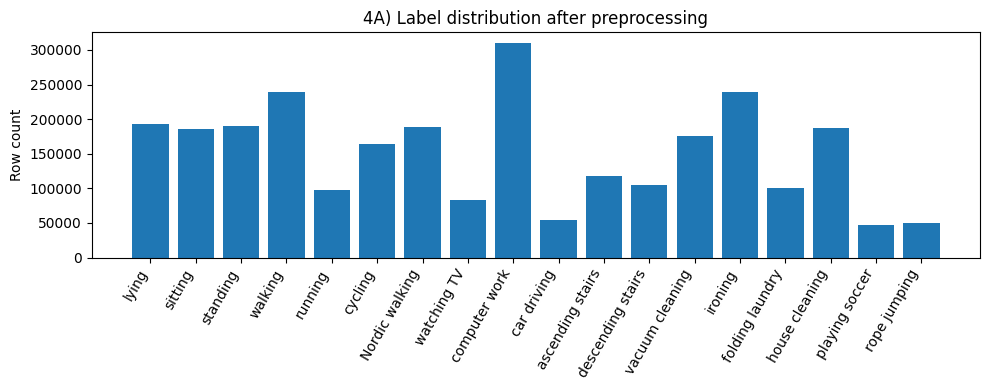

In [7]:
label_counts = df["label"].value_counts().sort_index()
names = [ACTIVITY_MAP.get(i, str(i)) for i in label_counts.index]

plt.figure(figsize=(10,4))
plt.bar(range(len(label_counts)), label_counts.values)
plt.xticks(range(len(label_counts)), names, rotation=60, ha="right")
plt.title("4A) Label distribution after preprocessing")
plt.ylabel("Row count")
plt.tight_layout()
plt.show()

## 5) Windowing + purity filtering

We convert the continuous streams into fixed-length examples:
- Window size = 5s at 100Hz → 500 samples (default)
- Stride = 250 (50% overlap)
- Purity filter keeps windows where the majority label dominates ≥ threshold

This reduces label noise (especially around transitions).

In [8]:
FEATURE_COLS = [c for c in df.columns if c not in ["subject","session","label"]]

WINDOW_SIZE_TRAIN = 1000 
WINDOW_SIZE_TEST = 1000
# STRIDE = 250
STRIDE_TRAIN = 200
STRIDE_TEST  = 200
PURITY_THRESH = 0.90

# def make_windows(df: pd.DataFrame, feature_cols, window_size, stride, purity_thresh):
#     X, y, purity, meta = [], [], [], []
#     for (subject, session), g in df.groupby(["subject","session"]):
#         g = g.sort_values("timestamp")
#         values = g[feature_cols].to_numpy(dtype=np.float32)
#         labels = g["label"].to_numpy(dtype=np.int64)
#         n = len(g)
#         for start in range(0, n - window_size + 1, stride):
#             end = start + window_size
#             wlab = labels[start:end]
#             binc = np.bincount(wlab)
#             maj = int(binc.argmax())
#             pur = float(binc.max()) / float(window_size)
#             if pur < purity_thresh:
#                 continue
#             X.append(values[start:end])
#             y.append(maj)
#             purity.append(pur)
#             meta.append((subject, session))
#     X = np.stack(X) if X else np.empty((0, window_size, len(feature_cols)), dtype=np.float32)
#     y = np.array(y, dtype=np.int64)
#     purity = np.array(purity, dtype=np.float32)
#     meta = pd.DataFrame(meta, columns=["subject","session"])
#     return X, y, purity, meta

def make_windows(df: pd.DataFrame, feature_cols, window_size, stride, purity_thresh):
    X, y, pur, meta = [], [], [], []
    for (subject, session), g in df.groupby(["subject","session"]):
        g = g.sort_values("timestamp")
        values = g[feature_cols].to_numpy(dtype=np.float32)
        labels = g["label"].to_numpy(dtype=np.int64)
        n = len(g)
        for start in range(0, n - window_size + 1, stride):
            end = start + window_size
            wlab = labels[start:end]
            binc = np.bincount(wlab)
            maj = int(binc.argmax())
            purity = float(binc.max()) / float(window_size)
            if purity < purity_thresh:
                continue
            X.append(values[start:end])
            y.append(maj)
            pur.append(purity)
            meta.append((subject, session))
    X = np.stack(X) if X else np.empty((0, window_size, len(feature_cols)), dtype=np.float32)
    y = np.array(y, dtype=np.int64)
    pur = np.array(pur, dtype=np.float32)
    meta = pd.DataFrame(meta, columns=["subject","session"])
    return X, y, pur, meta

# X, y, pur, meta = make_windows(df, FEATURE_COLS, WINDOW_SIZE_TRAIN, STRIDE, PURITY_THRESH)
# print("Windows:", X.shape, y.shape)
# print("Purity: min/mean/max =", float(pur.min()), float(pur.mean()), float(pur.max()))

# 1000-sample windows for training/validation
X_trw, y_trw, pur_tr, meta_tr = make_windows(df, FEATURE_COLS, WINDOW_SIZE_TRAIN, STRIDE_TRAIN, PURITY_THRESH)

# 1000-sample windows for few-shot testing
X_tew, y_tew, pur_te, meta_te = make_windows(df, FEATURE_COLS, WINDOW_SIZE_TEST,  STRIDE_TEST,  PURITY_THRESH)

print("Train/Val windows (1000):", X_trw.shape, y_trw.shape, "| purity mean:", float(pur_tr.mean()) if len(pur_tr) else None)
print("Test windows   (1000):", X_tew.shape, y_tew.shape, "| purity mean:", float(pur_te.mean()) if len(pur_te) else None)



Train/Val windows (1000): (13123, 1000, 32) (13123,) | purity mean: 0.9995628595352173
Test windows   (1000): (13123, 1000, 32) (13123,) | purity mean: 0.9995628595352173


### Visualisation 5A — Purity histogram

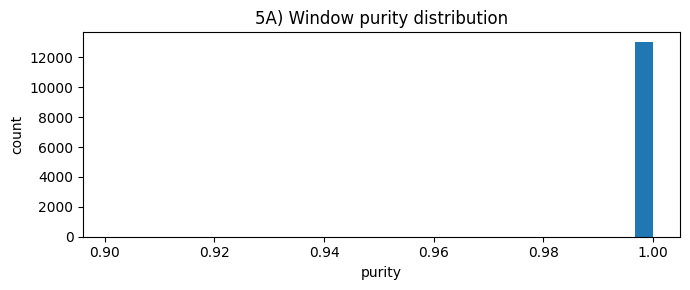

In [9]:
plt.figure(figsize=(7,3))
plt.hist(pur_tr, bins=30)
plt.title("5A) Window purity distribution")
plt.xlabel("purity")
plt.ylabel("count")
plt.tight_layout()
plt.show()

### Visualisation 5B — Example window plot (sanity check)

We plot a few sensor channels for a random window, just to verify signals look reasonable.

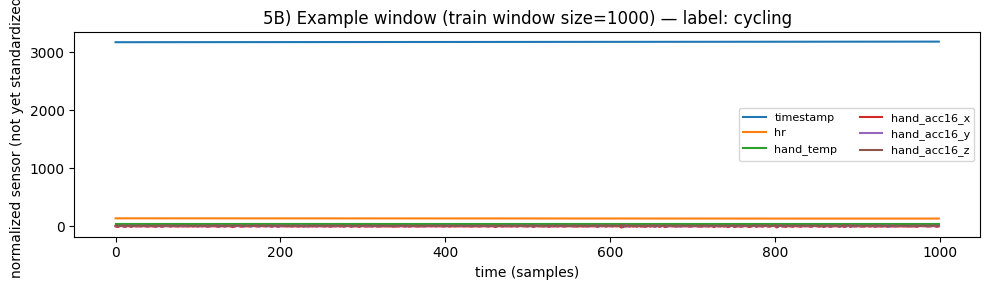

In [10]:
if len(X_trw) > 0:
    idx = np.random.randint(0, len(X_trw))
    plt.figure(figsize=(10,3))
    for ch in range(min(6, X_trw.shape[-1])):
        plt.plot(X_trw[idx, :, ch], label=FEATURE_COLS[ch])
    plt.title(f"5B) Example window (train window size={WINDOW_SIZE_TRAIN}) — label: {ACTIVITY_MAP.get(int(y_trw[idx]), y_trw[idx])}")
    plt.xlabel("time (samples)")
    plt.ylabel("normalized sensor (not yet standardized)")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

## 6) Train/Val/Test split + summary statistics

We do a **subject split**:
- reserve the last 2 subjects for testing (new people)
- training uses the remaining subjects

Then we enforce few-shot:
- Train/Val: **SEEN** classes only
- Test: **UNSEEN** classes only

This cell prints counts so you can track class imbalance and dataset size.

In [11]:
UNSEEN = [5,13,16,18]
ALL_LABELS = sorted(set(y_trw.tolist() + y_tew.tolist()))
UNSEEN = [l for l in UNSEEN if l in ALL_LABELS]
SEEN = [l for l in ALL_LABELS if l not in UNSEEN]

# ---------------------------
# Subject-wise split (NO leakage)
# ---------------------------
# We split by subject so that train/val/test come from disjoint subjects.
subjects = sorted(meta_tr["subject"].unique())

# Hold out last 2 subjects for TEST (or last 1 if not enough subjects)
test_subjects = subjects[-2:] if len(subjects) >= 4 else subjects[-1:]

# From the remaining subjects, hold out ~20% for VAL (at least 1 subject)
remain_subjects = [s for s in subjects if s not in test_subjects]
rng = np.random.default_rng(42)
rng.shuffle(remain_subjects)
n_val_subj = max(1, int(round(0.2 * len(remain_subjects))))
val_subjects = sorted(remain_subjects[:n_val_subj])
train_subjects = sorted(remain_subjects[n_val_subj:])

# Masks for TRAIN windows (meta_tr) and TEST windows (meta_te)
is_train_subj_tr = meta_tr["subject"].isin(train_subjects).values
is_val_subj_tr   = meta_tr["subject"].isin(val_subjects).values
is_test_subj_te  = meta_te["subject"].isin(test_subjects).values

# --- Train/Val: non-test subjects, SEEN only ---
X_train_all, y_train_all = X_trw[is_train_subj_tr], y_trw[is_train_subj_tr]
X_val_all,   y_val_all   = X_trw[is_val_subj_tr],   y_trw[is_val_subj_tr]

train_seen_mask = np.isin(y_train_all, SEEN)
val_seen_mask   = np.isin(y_val_all,   SEEN)

X_tr,  y_tr  = X_train_all[train_seen_mask], y_train_all[train_seen_mask]
X_val, y_val = X_val_all[val_seen_mask],     y_val_all[val_seen_mask]

# --- Test: held-out subjects, UNSEEN only ---
X_test_all, y_test_all = X_tew[is_test_subj_te], y_tew[is_test_subj_te]
test_unseen_mask = np.isin(y_test_all, UNSEEN)
X_test_u, y_test_u = X_test_all[test_unseen_mask], y_test_all[test_unseen_mask]

print("Train subjects:", train_subjects)
print("Val subjects:", val_subjects)
print("Test subjects:", test_subjects)
print("SEEN:", [ACTIVITY_MAP.get(i,i) for i in SEEN])
print("UNSEEN:", [ACTIVITY_MAP.get(i,i) for i in UNSEEN])
print("---")
print("Train seen:", X_tr.shape, "Val seen:", X_val.shape)
print("Test unseen:", X_test_u.shape)

Train subjects: ['subject101', 'subject102', 'subject103', 'subject105', 'subject106', 'subject107']
Val subjects: ['subject104']
Test subjects: ['subject108', 'subject109']
SEEN: ['lying', 'sitting', 'standing', 'walking', 'cycling', 'Nordic walking', 'watching TV', 'computer work', 'car driving', 'ascending stairs', 'ironing', 'house cleaning', 'playing soccer', 'rope jumping']
UNSEEN: ['running', 'descending stairs', 'vacuum cleaning', 'folding laundry']
---
Train seen: (7602, 1000, 32) Val seen: (949, 1000, 32)
Test unseen: (482, 1000, 32)


### Visualisation 6A — Train/Val/Test class counts

This shows imbalance, and also confirms the few-shot split:
- train/val contain only seen labels
- test contains only unseen labels

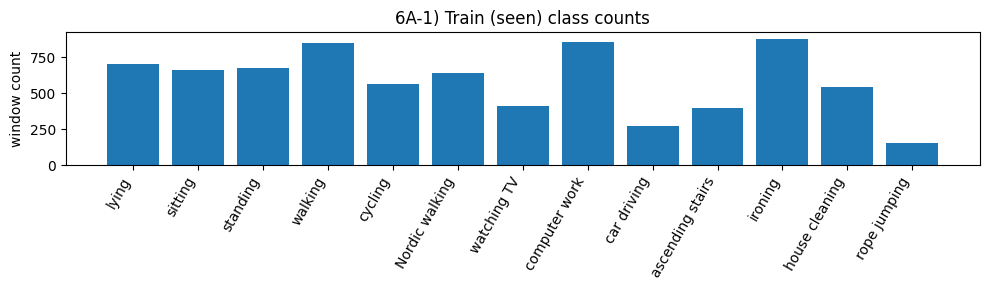

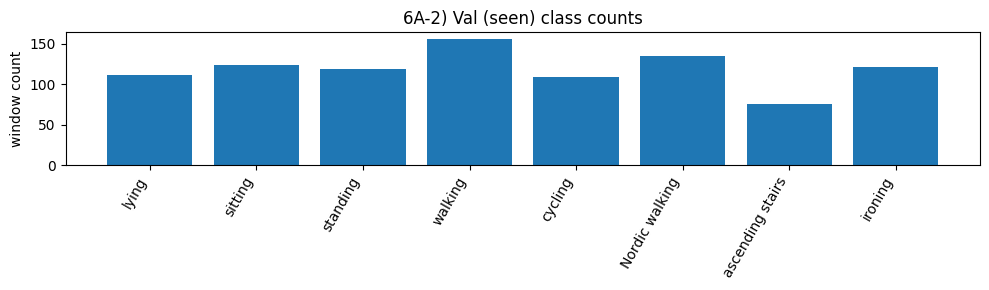

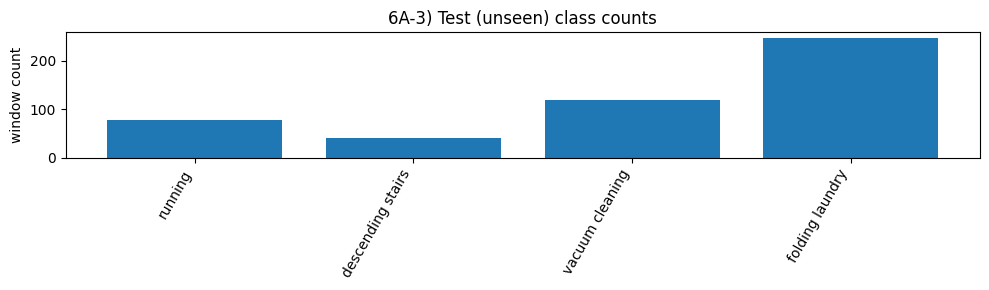

In [12]:
def plot_counts(y_arr, title):
    vc = pd.Series(y_arr).value_counts().sort_index()
    names = [ACTIVITY_MAP.get(i, str(i)) for i in vc.index]
    plt.figure(figsize=(10,3))
    plt.bar(range(len(vc)), vc.values)
    plt.xticks(range(len(vc)), names, rotation=60, ha="right")
    plt.title(title)
    plt.ylabel("window count")
    plt.tight_layout()
    plt.show()

plot_counts(y_tr, "6A-1) Train (seen) class counts")
plot_counts(y_val, "6A-2) Val (seen) class counts")
plot_counts(y_test_u, "6A-3) Test (unseen) class counts")

## 7) Standardize features using train statistics

We compute mean/std from **train seen windows only** and standardize train/val/test.
This prevents test leakage.

In [13]:
eps = 1e-3
mu = X_tr.reshape(-1, X_tr.shape[-1]).mean(axis=0)
sd = X_tr.reshape(-1, X_tr.shape[-1]).std(axis=0) + eps
sigma = sd  # alias for consistency

X_tr_n = (X_tr - mu) / sd
X_val_n = (X_val - mu) / sd
X_test_u_n = (X_test_u - mu) / sd

print("Standardized shapes:", X_tr_n.shape, X_val_n.shape, X_test_u_n.shape)


Standardized shapes: (7602, 1000, 32) (949, 1000, 32) (482, 1000, 32)


## 9) Datasets & DataLoaders

We use `num_workers=0` for macOS/Jupyter reliability.

In [14]:
class WindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

BATCH_SIZE = 256 if DEVICE == "cuda" else 64

train_loader = DataLoader(WindowDataset(X_tr_n, y_tr), batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda"), drop_last=True)
val_loader   = DataLoader(WindowDataset(X_val_n, y_val), batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda"))
test_loader  = DataLoader(WindowDataset(X_test_u_n, y_test_u), batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda"))

## 10) Time-series model: TCN 

Why TCN:
- Convolutions are fast (GPU-friendly)
- Dilations give long receptive field
- Works well for IMU time-series

Output:
- a **unit-normalized** embedding vector in the same space as label prototypes.

In [15]:
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=5, d=1, dropout=0.3):
        super().__init__()
        pad = (k - 1) * d // 2

        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size=k, dilation=d, padding=pad)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size=k, dilation=d, padding=pad)
        self.bn2   = nn.BatchNorm1d(out_ch)

        self.act = nn.ReLU()
        self.drop = nn.Dropout(dropout)

        self.res = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        h = self.conv1(x)
        h = self.bn1(h)
        h = self.act(h)
        h = self.drop(h)

        h = self.conv2(h)
        h = self.bn2(h)
        h = self.act(h)
        h = self.drop(h)

        return h + self.res(x)

class TCNEncoder(nn.Module):
    def __init__(self, n_features, channels=(64, 96, 128), k=5, dropout=0.3):
        super().__init__()
        blocks = []
        in_ch = n_features
        d = 1
        for out_ch in channels:
            blocks.append(TCNBlock(in_ch, out_ch, k=k, d=d, dropout=dropout))
            in_ch = out_ch
            d *= 2
        self.tcn = nn.Sequential(*blocks)
        self.ln = nn.LayerNorm(channels[-1])

    def forward(self, x):
        x = x.transpose(1,2)  # [B,F,T]
        x = self.tcn(x)       # [B,C,T]
        z = x.mean(dim=2)     # [B,C]
        return self.ln(z)

class BaseHARModel(nn.Module):
    """Standard supervised model on base (SEEN) classes.
    Then we do few-shot classification on UNSEEN classes using the encoder embedding space."""
    def __init__(self, n_features, n_classes, enc_channels=(64,96,128), k=5, dropout=0.3):
        super().__init__()
        self.enc = TCNEncoder(n_features, channels=enc_channels, k=k, dropout=dropout)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(enc_channels[-1], n_classes)
        )

    def forward(self, x, return_emb=False):
        z = self.enc(x)
        if return_emb:
            return z
        return self.classifier(z)

In [16]:

# --- Label mapping for SEEN classes (base classes) ---
seen_to_idx = {c:i for i,c in enumerate(SEEN)}
idx_to_seen = {i:c for c,i in seen_to_idx.items()}

# Instantiate model
model = BaseHARModel(n_features=X_tr_n.shape[-1], n_classes=len(SEEN)).to(DEVICE)
print("SEEN classes:", len(SEEN))
print("Params (M):", sum(p.numel() for p in model.parameters())/1e6)


SEEN classes: 14
Params (M): 0.275438


In [17]:
# --- Standard supervised training on SEEN classes (base training) ---
# Train a closed-set classifier on SEEN classes only, then reuse the encoder for few-shot classification on UNSEEN classes.
from sklearn.utils.class_weight import compute_class_weight


class AugmentedWindowDataset(Dataset):
    """On-the-fly augmentation for sensor HAR windows.
    Helps reduce subject-specific overfitting and improves held-out-subject test accuracy."""
    def __init__(self, X, y, noise_std=0.01, scale_range=(0.9, 1.1), time_mask_prob=0.15):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.noise_std = float(noise_std)
        self.scale_range = scale_range
        self.time_mask_prob = float(time_mask_prob)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y[idx]

        # Gaussian jitter
        if self.noise_std > 0:
            x = x + torch.randn_like(x) * self.noise_std

        # Random per-channel scaling
        lo, hi = self.scale_range
        if hi > lo:
            scale = torch.empty((1, x.shape[1])).uniform_(lo, hi)
            x = x * scale

        # Time masking (randomly zero a short segment)
        if self.time_mask_prob > 0 and torch.rand(1).item() < self.time_mask_prob:
            T = x.shape[0]
            mask_len = max(10, int(0.05 * T))
            start = torch.randint(0, max(1, T - mask_len), (1,)).item()
            x[start:start+mask_len, :] = 0.0

        return x, y


def map_seen_labels(y_arr):
    return np.array([seen_to_idx[int(y)] for y in y_arr], dtype=np.int64)

y_tr_idx = map_seen_labels(y_tr)
y_val_idx = map_seen_labels(y_val)

train_ds = AugmentedWindowDataset(X_tr_n, y_tr_idx, noise_std=0.01, scale_range=(0.9,1.1), time_mask_prob=0.15)
val_ds   = WindowDataset(X_val_n, y_val_idx)

BATCH = 256
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=NUM_WORKERS, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS)

# Class-balanced loss (helps on HAR class imbalance)
# NOTE: Some SEEN classes may have 0 samples in the train split (subject-held-out).
# CrossEntropyLoss expects a weight for ALL classes (len(SEEN)), so we build a full vector.
NUM_SEEN = len(SEEN)
present = np.unique(y_tr_idx)

w_present = compute_class_weight(class_weight="balanced", classes=present, y=y_tr_idx)
w_full = np.ones(NUM_SEEN, dtype=np.float32)
w_full[present] = w_present.astype(np.float32)

w = torch.tensor(w_full, dtype=torch.float32).to(DEVICE)

# Label smoothing improves generalization a bit for noisy HAR labels
crit = nn.CrossEntropyLoss(weight=w, label_smoothing=0.05)

opt = torch.optim.AdamW(model.parameters(), lr=8e-4, weight_decay=5e-4)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode="max", factor=0.5, patience=2
)

@torch.no_grad()
def eval_seen_acc(loader):
    model.eval()
    correct, total = 0, 0
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        logits = model(xb)
        pred = torch.argmax(logits, dim=1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)
    return correct / max(total, 1)

EPOCHS = 60
patience = 6
best_val = -1.0
best_state = None
pat = 0

train_losses, val_accs = [], []

for ep in range(1, EPOCHS+1):
    model.train()
    total_loss = 0.0
    total = 0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        opt.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = crit(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        total_loss += loss.item() * yb.size(0)
        total += yb.size(0)

    avg_loss = total_loss / max(total, 1)
    va = eval_seen_acc(val_loader)
    sched.step(va)

    train_losses.append(avg_loss)
    val_accs.append(va)
    print(f"Epoch {ep:02d} | loss={avg_loss:.4f} | val_seen_acc={va:.4f} | lr={opt.param_groups[0]['lr']:.2e}")

    # Early stopping on subject-held-out validation
    if va > best_val + 1e-4:
        best_val = va
        best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
        pat = 0
    else:
        pat += 1
        if pat >= patience:
            break

# # Restore best model
# if best_state is not None:
#     model.load_state_dict({k: v.to(DEVICE) for k,v in best_state.items()})

# plt.figure(figsize=(7,3))
# plt.plot(train_losses, label="train loss")
# plt.plot(val_accs, label="val seen acc")
# plt.axhline(best_val, linestyle="--", label="best val")
# plt.legend()
# plt.title("Base training curves (SEEN, subject-held-out VAL)")
# plt.show()

Epoch 01 | loss=0.7336 | val_seen_acc=0.9831 | lr=8.00e-04
Epoch 02 | loss=0.4119 | val_seen_acc=0.9737 | lr=8.00e-04
Epoch 03 | loss=0.3912 | val_seen_acc=0.9852 | lr=8.00e-04
Epoch 04 | loss=0.3860 | val_seen_acc=0.9705 | lr=8.00e-04
Epoch 05 | loss=0.3803 | val_seen_acc=0.9916 | lr=8.00e-04
Epoch 06 | loss=0.3799 | val_seen_acc=0.9958 | lr=8.00e-04
Epoch 07 | loss=0.3771 | val_seen_acc=0.9874 | lr=8.00e-04
Epoch 08 | loss=0.3760 | val_seen_acc=0.9884 | lr=8.00e-04
Epoch 09 | loss=0.3755 | val_seen_acc=0.9842 | lr=4.00e-04
Epoch 10 | loss=0.3742 | val_seen_acc=0.9863 | lr=4.00e-04
Epoch 11 | loss=0.3732 | val_seen_acc=0.9863 | lr=4.00e-04
Epoch 12 | loss=0.3723 | val_seen_acc=0.9874 | lr=2.00e-04


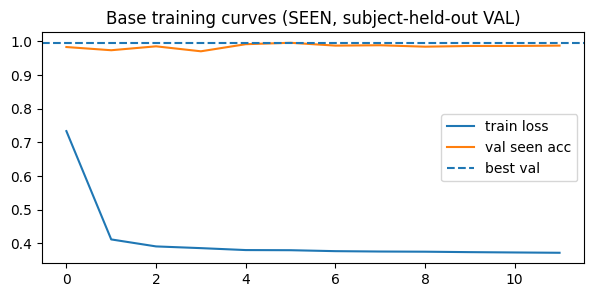

In [21]:
# Restore best model
if best_state is not None:
    model.load_state_dict({k: v.to(DEVICE) for k,v in best_state.items()})

plt.figure(figsize=(7,3))
plt.plot(train_losses, label="train loss")
plt.plot(val_accs, label="val seen acc")
plt.axhline(best_val, linestyle="--", label="best val")
plt.legend()
plt.title("Base training curves (SEEN, subject-held-out VAL)")
plt.show()

In [22]:

# --- SEEN test set from held-out test subjects ---
test_seen_mask = np.isin(y_test_all, SEEN)
X_test_s, y_test_s = X_test_all[test_seen_mask], y_test_all[test_seen_mask]

# Normalize using the same train stats (mu, sd)
X_test_s_n = (X_test_s - mu) / sd
X_test_u_n = (X_test_u - mu) / sd

y_test_s_idx = map_seen_labels(y_test_s)
seen_test_loader = DataLoader(WindowDataset(X_test_s_n, y_test_s_idx), batch_size=256, shuffle=False, num_workers=NUM_WORKERS)

seen_acc = eval_seen_acc(seen_test_loader)
print("SEEN test acc (base classifier):", seen_acc)
print("SEEN test size:", X_test_s.shape, "| UNSEEN test size:", X_test_u.shape)


SEEN test acc (base classifier): 0.43343386471348555
SEEN test size: (2321, 1000, 32) | UNSEEN test size: (482, 1000, 32)


## Few-shot learning on UNSEEN classes (k-shot)

This section implements **few-shot learning** (**not** zero-shot learning):

- We sample **k labeled support windows per UNSEEN class** from held-out **test subjects**.
- We embed each window using the trained **SEEN encoder** (a standard supervised base model).
- We compute a **prototype** per UNSEEN class by averaging the support embeddings.
- We classify the remaining UNSEEN windows (the **query** set) by **nearest prototype** using cosine similarity.

Why this is useful on PAMAP2:
- Sensor HAR has **high overlap** between activities and strong **subject-specific patterns**.
- A small amount of labeled data per new activity (k-shot) is often more realistic than assuming *zero* labels.

We report (same style as earlier):
- **SEEN accuracy** (base classifier on SEEN test windows)
- **UNSEEN accuracy** (few-shot on UNSEEN query windows)
- **Harmonic mean H** between seen/unseen
- **Collapse diagnostics** (to ensure predictions are not dominated by a single class)
- **Confusion matrix** + per-class accuracy for interpretability


,k,seen_acc,unseen_acc_mean,unseen_acc_std,H,top_class_frac_mean,norm_entropy_mean
0,1,0.433434,0.771548,0.082453,0.555054,0.370711,0.940763
1,2,0.433434,0.781013,0.047763,0.557484,0.340084,0.956483
2,5,0.433434,0.896537,0.117119,0.584358,0.439394,0.903052
3,10,0.433434,0.854299,0.108565,0.575091,0.400452,0.924009


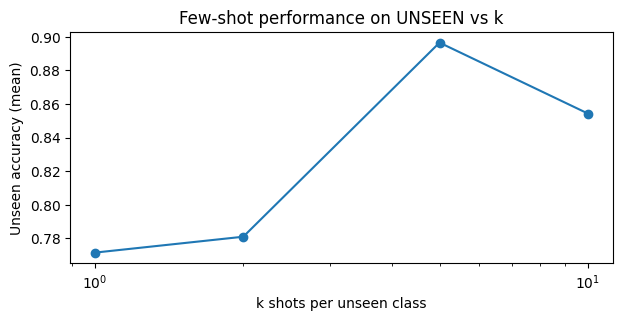

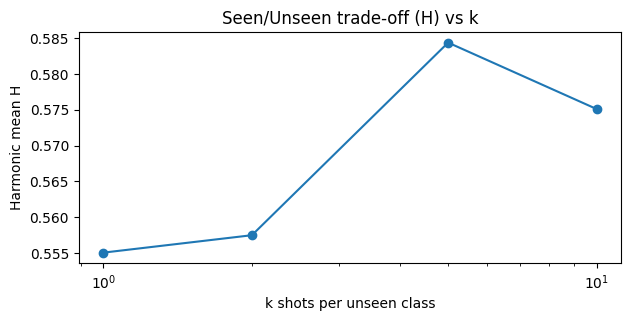

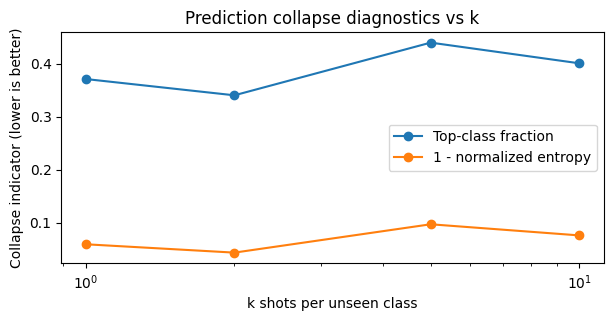

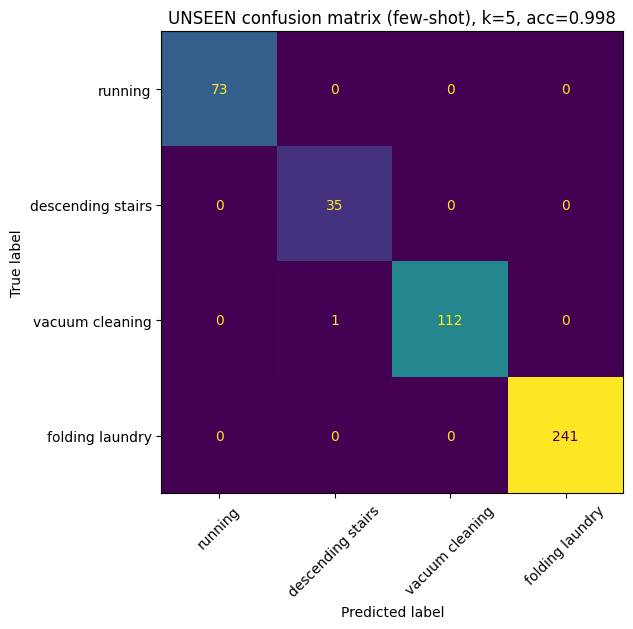

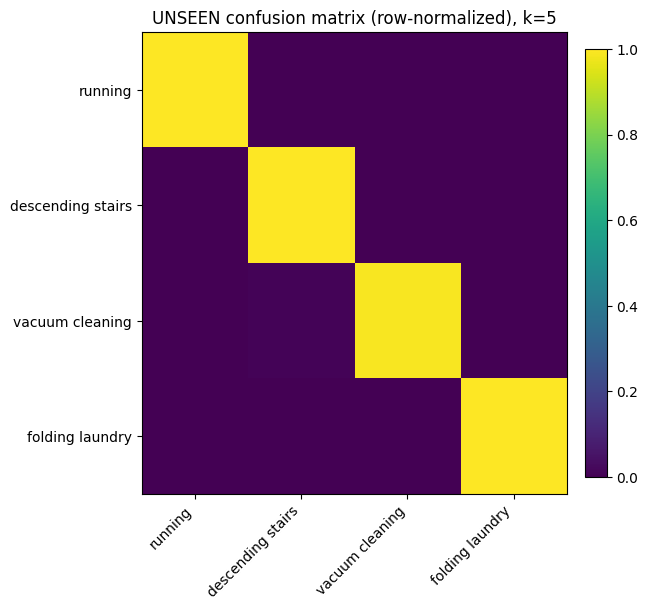

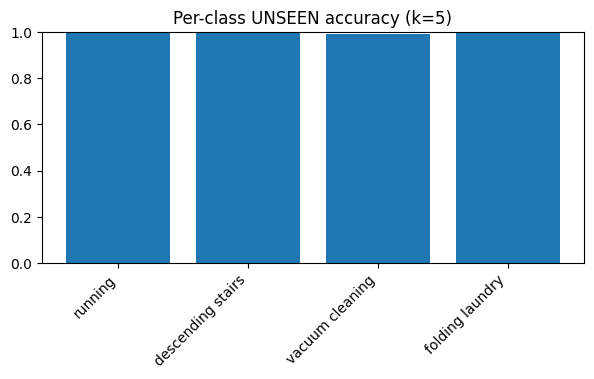

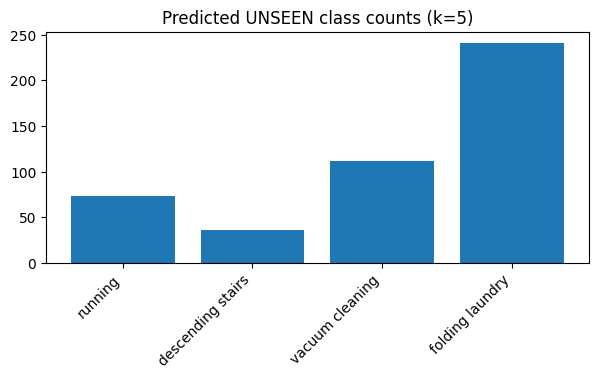

In [23]:

import math
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

@torch.no_grad()
def embed_batch(X_np, batch_size=256):
    model.eval()
    embs = []
    dl = DataLoader(WindowDataset(X_np, np.zeros(len(X_np), dtype=np.int64)), batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
    for xb, _ in dl:
        xb = xb.to(DEVICE)
        z = model(xb, return_emb=True)
        z = z / (z.norm(dim=1, keepdim=True) + 1e-8)
        embs.append(z.cpu())
    return torch.cat(embs, dim=0)

def fewshot_split_indices(y_arr, classes, k, rng):
    support_idx = []
    query_idx = []
    y_arr = np.asarray(y_arr)
    for c in classes:
        idx = np.where(y_arr == c)[0]
        rng.shuffle(idx)
        take = idx[:k]
        rest = idx[k:]
        support_idx.extend(take.tolist())
        query_idx.extend(rest.tolist())
    return np.array(support_idx), np.array(query_idx)

@torch.no_grad()
def fewshot_eval(X_u, y_u, k=1, repeats=5, batch_size=256):
    rng = np.random.default_rng(SEED)
    unseen_list = list(UNSEEN)
    accs = []
    collapse_top_frac = []
    norm_entropy = []
    best = None

    # Precompute embeddings once (speed)
    E = embed_batch(X_u, batch_size=batch_size).numpy()   # shape: (N, D)

    for r in range(repeats):
        s_idx, q_idx = fewshot_split_indices(y_u, unseen_list, k=k, rng=rng)
        if len(q_idx) == 0:
            continue

        y_s = np.asarray(y_u)[s_idx]
        y_q = np.asarray(y_u)[q_idx]
        E_s = E[s_idx]   # (Ns, D)
        E_q = E[q_idx]   # (Nq, D)

        # --- prototypes: mean embedding per unseen class ---
        protos = []
        for c in unseen_list:
            cls_idx = np.where(y_s == c)[0]
            if len(cls_idx) == 0:
                # If a class has <k samples (rare), use zeros to avoid crash
                proto = np.zeros(E.shape[1], dtype=np.float32)
            else:
                proto = E_s[cls_idx].mean(axis=0)
            # normalize proto for cosine similarity
            proto = proto / (np.linalg.norm(proto) + 1e-8)
            protos.append(proto)

        protos = np.stack(protos, axis=0)  # (num_unseen, D)

        # --- cosine similarity between queries and prototypes ---
        # E_q is already L2-normalized from embed_batch
        sims = E_q @ protos.T  # (Nq, num_unseen)

        pred_i = sims.argmax(axis=1)
        pred = np.array([unseen_list[i] for i in pred_i], dtype=int)

        acc = (pred == y_q).mean()
        accs.append(acc)

        # collapse diagnostics
        vals, counts = np.unique(pred, return_counts=True)
        top_frac = counts.max() / counts.sum()
        collapse_top_frac.append(top_frac)

        p = counts / counts.sum()
        ent = -np.sum(p * np.log(p + 1e-12))
        ent_norm = ent / np.log(len(unseen_list) + 1e-12)
        norm_entropy.append(ent_norm)

        # keep best run for confusion matrix
        if best is None or acc > best[0]:
            best = (acc, y_q, pred)

    return {
        "unseen_acc_mean": float(np.mean(accs)) if accs else float("nan"),
        "unseen_acc_std": float(np.std(accs)) if accs else float("nan"),
        "top_class_frac_mean": float(np.mean(collapse_top_frac)) if collapse_top_frac else float("nan"),
        "norm_entropy_mean": float(np.mean(norm_entropy)) if norm_entropy else float("nan"),
        "best_run": best
    }


def harmonic_mean(a,b):
    return (2*a*b)/(a+b+1e-12)

K_LIST = [1,2,5,10]
REPEATS = 5
rows = []
best_k = None
best_H = -1

for k in K_LIST:
    out = fewshot_eval(X_test_u_n, y_test_u, k=k, repeats=REPEATS)
    unseen_acc = out["unseen_acc_mean"]
    H = harmonic_mean(seen_acc, unseen_acc)
    rows.append({
        "k": k,
        "seen_acc": seen_acc,
        "unseen_acc_mean": unseen_acc,
        "unseen_acc_std": out["unseen_acc_std"],
        "H": H,
        "top_class_frac_mean": out["top_class_frac_mean"],
        "norm_entropy_mean": out["norm_entropy_mean"]
    })
    if H > best_H:
        best_H = H
        best_k = k

df_fs = pd.DataFrame(rows)
display(df_fs)

plt.figure(figsize=(7,3))
plt.plot(df_fs["k"], df_fs["unseen_acc_mean"], marker="o")
plt.xscale("log")
plt.xlabel("k shots per unseen class")
plt.ylabel("Unseen accuracy (mean)")
plt.title("Few-shot performance on UNSEEN vs k")
plt.show()

plt.figure(figsize=(7,3))
plt.plot(df_fs["k"], df_fs["H"], marker="o")
plt.xscale("log")
plt.xlabel("k shots per unseen class")
plt.ylabel("Harmonic mean H")
plt.title("Seen/Unseen trade-off (H) vs k")
plt.show()

plt.figure(figsize=(7,3))
plt.plot(df_fs["k"], df_fs["top_class_frac_mean"], marker="o", label="Top-class fraction")
plt.plot(df_fs["k"], 1-df_fs["norm_entropy_mean"], marker="o", label="1 - normalized entropy")
plt.xscale("log")
plt.xlabel("k shots per unseen class")
plt.ylabel("Collapse indicator (lower is better)")
plt.legend()
plt.title("Prediction collapse diagnostics vs k")
plt.show()

# Confusion matrix for best-k (best run)
out_best = fewshot_eval(X_test_u_n, y_test_u, k=best_k, repeats=REPEATS)
best = out_best["best_run"]
if best is not None:
    acc_best, y_q, pred = best
    labels = list(UNSEEN)
    cm = confusion_matrix(y_q, pred, labels=labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=[ACTIVITY_MAP.get(i,str(i)) for i in labels])
    fig, ax = plt.subplots(figsize=(6,6))
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    plt.title(f"UNSEEN confusion matrix (few-shot), k={best_k}, acc={acc_best:.3f}")
    plt.show()

    # Normalized confusion matrix (row-normalized) + per-class accuracy
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-12)
    fig, ax = plt.subplots(figsize=(6,6))
    im = ax.imshow(cm_norm, aspect="auto")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels([ACTIVITY_MAP.get(i,str(i)) for i in labels], rotation=45, ha="right")
    ax.set_yticklabels([ACTIVITY_MAP.get(i,str(i)) for i in labels])
    ax.set_title(f"UNSEEN confusion matrix (row-normalized), k={best_k}")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

    per_class_acc = np.diag(cm) / (cm.sum(axis=1) + 1e-12)
    plt.figure(figsize=(7,3))
    plt.bar([ACTIVITY_MAP.get(i,str(i)) for i in labels], per_class_acc)
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0,1)
    plt.title(f"Per-class UNSEEN accuracy (k={best_k})")
    plt.show()

    # Predicted class distribution (collapse visual)
    vc = pd.Series(pred).value_counts().reindex(labels, fill_value=0)
    plt.figure(figsize=(7,3))
    plt.bar([ACTIVITY_MAP.get(i,str(i)) for i in labels], vc.values)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Predicted UNSEEN class counts (k={best_k})")
    plt.show()
